In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #该语句解决图像中的“-”负号的乱码问题

In [9]:
data_train=pd.read_csv('F:/TensorFlow/traindata20241213原数据.csv',header=0,encoding='utf_8')
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17964 entries, 0 to 17963
Columns: 256 entries, ClassName to Wgs84Y
dtypes: float64(26), int64(229), object(1)
memory usage: 35.1+ MB


In [10]:
data_Kp = data_train[data_train['ClassName'] == '高山嵩草（Kobresia pygmaea）草甸']['DEM1']
data_Sp = data_train[data_train['ClassName'] == '紫花针茅（Stipa purpurea）草原']['DEM1']
data_En = data_train[data_train['ClassName'] == '垂穗披碱草（Elymus nutans）高寒草甸']['DEM1']
data_Kh = data_train[data_train['ClassName'] == '矮生嵩草（Kobresia humilis）草甸']['DEM1']
data_Kl = data_train[data_train['ClassName'] == '藏北嵩草（Kobresia littledalei）沼泽草甸']['DEM1']
data_Pp = data_train[data_train['ClassName'] == '细叶早熟禾（Poa pratensis subsp. angustifolia）草甸草原']['DEM1']
data_Sb = data_train[data_train['ClassName'] == '长芒草（Stipa bungeana）草原']['DEM1']
data_Cm = data_train[data_train['ClassName'] == '青藏薹草（Carex moorcroftii）高寒草原']['DEM1']
#data_St = data_train[data_train['ClassName'] == '戈壁针茅（Stipa tianschanica var. gobica）荒漠草原']['DEM1']
#data_Sg = data_train[data_train['ClassName'] == '沙生针茅（Stipa glareosa）荒漠草原']['DEM1']
#data_Sr = data_train[data_train['ClassName'] == '昆仑针茅（Stipa roborowskyi）草原']['DEM1']
#data_Ss = data_train[data_train['ClassName'] == '羽柱针茅（Stipa subsessiliflora var. basiplumosa）草原']['DEM1']
#data_Ai = data_train[data_train['ClassName'] == '醉马草（Achnatherum inebrians）草原']['DEM1']
#data_As = data_train[data_train['ClassName'] == '芨芨草（Achnatherum splendens）草原']['DEM1']

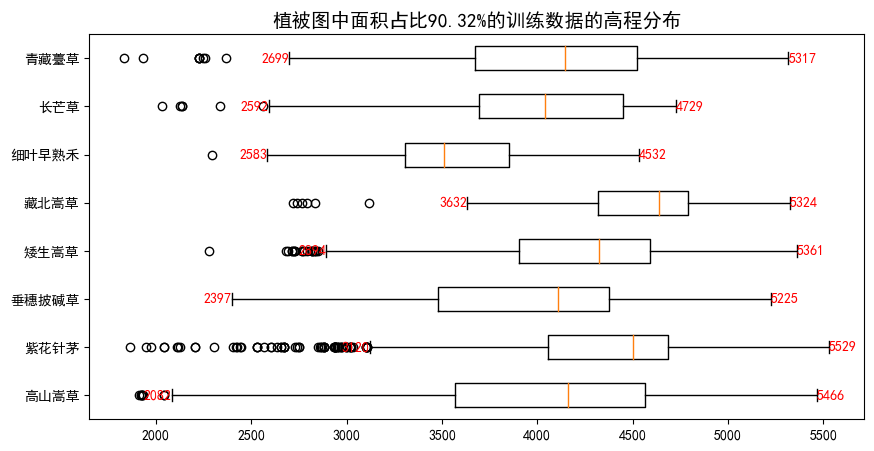

In [15]:
plt.figure(figsize=(10,5))#设置画布的尺寸
plt.title('植被图中面积占比90.32%的训练数据的高程分布',fontsize=14)#标题，并设定字号大小
#plt.title('植被图中海拔与文献差异较大的类型\n的训练数据的高程分布',fontsize=14)#标题，并设定字号大小
#labels = '戈壁针茅\n荒漠草原','沙生针茅\n荒漠草原', '昆仑针茅草原', '羽柱针茅草原', '醉马草草原','芨芨草草原'#图例
labels = '高山嵩草', '紫花针茅', '垂穗披碱草', '矮生嵩草', '藏北嵩草', '细叶早熟禾', '长芒草', '青藏薹草'#图例

#vert=False:水平箱线图；showmeans=True：显示均值
bp = plt.boxplot([data_Kp, data_Sp, data_En, data_Kh, data_Kl, data_Pp, data_Sb, data_Cm], labels = labels, vert=False,)
#plt.boxplot([data_St, data_Sg, data_Sr, data_Ss,  data_Ai, data_As], labels = labels, vert=False,)

# 获取须的坐标
whis = bp['whiskers']

# 每两个whiskers对应一组数据的上下须
for i in range(0, len(whis), 2):
    # 获取下须的x值（最小值）
    lower = whis[i].get_xdata()[1]  # 改用get_xdata
    # 获取上须的x值（最大值）
    upper = whis[i+1].get_xdata()[1]  # 改用get_xdata
    
    # 获取y坐标（位置）
    y_pos = whis[i].get_ydata()[1]
    
    # 添加标注
    plt.text(lower, y_pos, f'{lower:.0f}', 
             ha='right', va='center', color='red')
    plt.text(upper, y_pos, f'{upper:.0f}', 
             ha='left', va='center', color='red')


plt.show()#显示图像